In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loading EEG data...
done.

Dropping corrupted FADHD subject (#7)...
Excluding cells 8, 9, 10 (confirmed duplicates). Keeping original cells: [1, 2, 3, 4, 5, 6, 7, 11]

Running preprocessing + epoching (paper method) on all 4 groups (8 cells each)...
  FC...
  MC...
  FADHD...
  MADHD...
preprocessing + epoching done.

Total signals processed: 1264
Total samples clipped by artifact rejection (|z| > 5): 15446

Epoch count per subject/cell -> min: 5, max: 15, mean: 9.6

Saving preprocessed + epoched datasets (paper method)...
  Saved FC -> /content/drive/MyDrive/ADHD_EEG_Project/data/preprocessed_paper_method/FC_preprocessed_paper.mat
  Saved MC -> /content/drive/MyDrive/ADHD_EEG_Project/data/preprocessed_paper_method/MC_preprocessed_paper.mat
  Saved FADHD -> /content/drive/MyDrive/ADHD_EEG_Project/data/preprocessed_paper_method/FADHD_preprocessed_paper.mat
  S

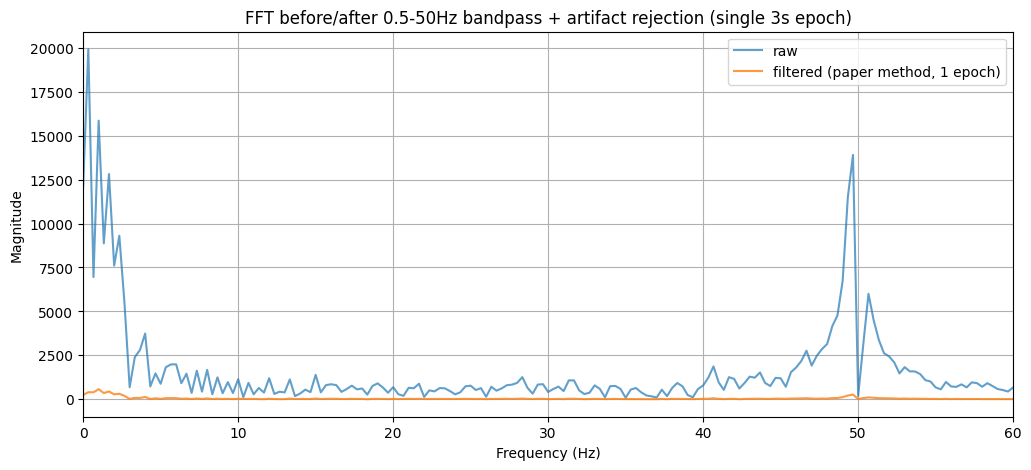


Summary
Subjects -> FC: 13, MC: 29, FADHD: 10, MADHD: 27
Total subjects: 79
Epoch length: 3.0s (768 samples at 256Hz), non-overlapping

METHODOLOGY NOTE (for your paper): This preprocessing adapts Chen et al. (2022)'s methodology for this dataset's 2-channel-per-cell structure. Their ICA-based artifact removal requires enough simultaneously-recorded channels to separate artifact sources from brain signal (they used 8); with only 2 channels per cell, ICA cannot perform this separation meaningfully. Amplitude-based artifact rejection (winsorization, |z|>5) was used as a documented substitute, achieving the same practical goal (suppressing extreme blink/muscle artifact spikes) without requiring multi-channel source separation. Signals were additionally segmented into non-overlapping 3-second epochs (matching the paper's resting-epoch length) prior to feature extraction, so that connectivity is computed per epoch and averaged, rather than over the entire continuous signal.

Preprocessing 

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

from scipy.io import loadmat, savemat
from scipy.signal import butter, filtfilt
from google.colab import drive

# CONSTANTS


FS = 256  # sampling rate, Hz

EPOCH_SEC = 3.0                              # matches paper's resting epoch length
EPOCH_LEN = int(EPOCH_SEC * FS)              # 768 samples per epoch

# Original cell indices (1-indexed) that are KEPT, in order.
# Cells 8, 9, 10 excluded - confirmed duplicates of cells 2, 3, 4.
KEPT_ORIGINAL_CELLS = [1, 2, 3, 4, 5, 6, 7, 11]
N_CELLS = len(KEPT_ORIGINAL_CELLS)  # 8

CELL_INFO = {
    1: {"original_cell": 1,  "task": "Eyes open baseline",        "channels": ("Cz", "F4")},
    2: {"original_cell": 2,  "task": "Eyes closed",                "channels": ("Cz", "F4")},
    3: {"original_cell": 3,  "task": "Eyes open",                  "channels": ("Cz", "F4")},
    4: {"original_cell": 4,  "task": "Cognitive challenge",        "channels": ("Cz", "F4")},
    5: {"original_cell": 5,  "task": "Pre-omni harmonic baseline", "channels": ("Cz", "F4")},
    6: {"original_cell": 6,  "task": "Omni harmonic assessment",   "channels": ("Cz", "F4")},
    7: {"original_cell": 7,  "task": "Eyes open baseline",         "channels": ("O1", "F4")},
    8: {"original_cell": 11, "task": "Eyes closed",                "channels": ("Fz", "F4")},
}

drive.mount('/content/drive')

PROJECT_PATH = "/content/drive/MyDrive/ADHD_EEG_Project"
DATA_DIR = os.path.join(PROJECT_PATH, "data", "raw")

# Output folder - keeps this paper-method run fully separate from
# other (non-paper-method) preprocessed files.
PROCESSED_DIR = os.path.join(PROJECT_PATH, "data", "preprocessed_paper_method")
os.makedirs(PROCESSED_DIR, exist_ok=True)


# LOAD RAW DATA

print("Loading EEG data...")
FC_raw    = loadmat(f"{DATA_DIR}/FC.mat")["FC"]
MC_raw    = loadmat(f"{DATA_DIR}/MC.mat")["MC"]
FADHD_raw = loadmat(f"{DATA_DIR}/FADHD.mat")["FADHD"]
MADHD_raw = loadmat(f"{DATA_DIR}/MADHD.mat")["MADHD"]
print("done.\n")


# --- drop corrupted subject ---
print("Dropping corrupted FADHD subject (#7)...")
for cell in range(11):
    FADHD_raw[0, cell] = np.delete(FADHD_raw[0, cell], 6, axis=0)


# --- exclude duplicated cells 8, 9, 10 ---
def subset_cells(raw_data, kept_original_cells):
    subset = np.empty((1, len(kept_original_cells)), dtype=object)
    for new_idx, original_cell_num in enumerate(kept_original_cells):
        original_idx = original_cell_num - 1
        subset[0, new_idx] = raw_data[0, original_idx]
    return subset


print(f"Excluding cells 8, 9, 10 (confirmed duplicates). Keeping original cells: {KEPT_ORIGINAL_CELLS}\n")

FC    = subset_cells(FC_raw, KEPT_ORIGINAL_CELLS)
MC    = subset_cells(MC_raw, KEPT_ORIGINAL_CELLS)
FADHD = subset_cells(FADHD_raw, KEPT_ORIGINAL_CELLS)
MADHD = subset_cells(MADHD_raw, KEPT_ORIGINAL_CELLS)

# PREPROCESSING

def bandpass_filter(signal, low=0.5, high=50, fs=FS, order=4):
    nyq = fs / 2
    high = min(high, nyq - 1)  # guard against Nyquist edge cases
    b, a = butter(order, [low / nyq, high / nyq], btype="band")
    return filtfilt(b, a, signal)


def reject_artifacts(signal, z_thresh=5.0):

    mean, std = np.mean(signal), np.std(signal)
    if std == 0:
        return signal
    z = (signal - mean) / std
    z_clipped = np.clip(z, -z_thresh, z_thresh)
    return z_clipped * std + mean


def normalize_signal(signal):
    mean, std = np.mean(signal), np.std(signal)
    if std == 0:
        return signal - mean
    return (signal - mean) / std


def epoch_signal(two_channel_signal, epoch_len=EPOCH_LEN):

    n_samples = two_channel_signal.shape[0]
    n_epochs = n_samples // epoch_len

    if n_epochs == 0:
        return np.empty((0, epoch_len, 2))

    trimmed = two_channel_signal[: n_epochs * epoch_len]
    epochs = trimmed.reshape(n_epochs, epoch_len, 2)
    return epochs


def preprocess_and_epoch(eeg):

    processed = np.zeros_like(eeg, dtype=float)
    n_clipped = 0

    for ch_idx in [0, 1]:
        raw_ch = eeg[:, ch_idx].copy()
        filtered = bandpass_filter(raw_ch)

        mean, std = np.mean(filtered), np.std(filtered)
        if std > 0:
            z = (filtered - mean) / std
            n_clipped += int(np.sum(np.abs(z) > 5.0))

        rejected = reject_artifacts(filtered)
        processed[:, ch_idx] = normalize_signal(rejected)

    epoched = epoch_signal(processed)
    return epoched, n_clipped


datasets = {"FC": FC, "MC": MC, "FADHD": FADHD, "MADHD": MADHD}


# RUN PREPROCESSING + EPOCHING

print("Running preprocessing + epoching (paper method) on all 4 groups (8 cells each)...")

preprocessed = {}
subject_counts = {}
total_signals = 0
total_clipped_samples = 0
epoch_count_report = []  # (dataset, cell, subject, n_epochs)

for name, data in datasets.items():
    print(f"  {name}...")
    processed_cells = []
    counts_this_dataset = []

    for cell in range(N_CELLS):
        n_subj = data[0, cell].shape[0]
        counts_this_dataset.append(n_subj)

        # object array since n_epochs can vary by subject
        processed_subjects = np.empty(n_subj, dtype=object)

        for subj in range(n_subj):
            eeg = data[0, cell][subj]
            epoched, n_clipped = preprocess_and_epoch(eeg)

            processed_subjects[subj] = epoched
            total_clipped_samples += n_clipped
            total_signals += 2
            epoch_count_report.append((name, cell, subj, epoched.shape[0]))

        processed_cells.append(processed_subjects)

    preprocessed[name] = processed_cells
    subject_counts[name] = counts_this_dataset

print("preprocessing + epoching done.\n")
print(f"Total signals processed: {total_signals}")
print(f"Total samples clipped by artifact rejection (|z| > 5): {total_clipped_samples}")

epoch_counts = np.array([e[3] for e in epoch_count_report])
print(f"\nEpoch count per subject/cell -> min: {epoch_counts.min()}, "
      f"max: {epoch_counts.max()}, mean: {epoch_counts.mean():.1f}")
if epoch_counts.min() == 0:
    n_zero = int(np.sum(epoch_counts == 0))
    print(f"  WARNING: {n_zero} subject/cell combinations produced 0 epochs "
          f"(signal shorter than {EPOCH_SEC}s). These will contribute no "
          f"connectivity data for that cell during feature extraction.")


print("\nSaving preprocessed + epoched datasets (paper method)...")

for name, processed_data in preprocessed.items():
    output_path = os.path.join(PROCESSED_DIR, f"{name}_preprocessed_paper.mat")

    mat_cells = np.empty((1, N_CELLS), dtype=object)
    for cell in range(N_CELLS):
        mat_cells[0, cell] = processed_data[cell]

    savemat(output_path, {name: mat_cells})
    print(f"  Saved {name} -> {output_path}")

print("\nAll processed datasets saved.")


# FFT SANITY CHECK PLOT (first epoch of first subject, cell 1)

print("\nGenerating FFT comparison plot (FC, cell 1, subject 1, first epoch)...")

raw_signal = FC[0, 0][0][:EPOCH_LEN, 0]
processed_epochs = preprocessed["FC"][0][0]  # shape (n_epochs, EPOCH_LEN, 2)

if processed_epochs.shape[0] > 0:
    processed_signal = processed_epochs[0, :, 0]

    N_samples = len(raw_signal)
    freq = np.fft.fftfreq(N_samples, d=1 / FS)
    raw_fft = np.abs(np.fft.fft(raw_signal))
    proc_fft = np.abs(np.fft.fft(processed_signal))

    plt.figure(figsize=(12, 5))
    plt.plot(freq[:N_samples // 2], raw_fft[:N_samples // 2], label="raw", alpha=0.7)
    plt.plot(freq[:N_samples // 2], proc_fft[:N_samples // 2], label="filtered (paper method, 1 epoch)", alpha=0.8)
    plt.xlim(0, 60)
    plt.xlabel("Frequency (Hz)")
    plt.ylabel("Magnitude")
    plt.title("FFT before/after 0.5-50Hz bandpass + artifact rejection (single 3s epoch)")
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("  Skipped: cell 1 / subject 1 produced 0 epochs.")


# SUMMARY


total_subjects = sum(subject_counts[name][0] for name in datasets.keys())

print("\nSummary")
print(f"Subjects -> FC: {subject_counts['FC'][0]}, MC: {subject_counts['MC'][0]}, "
      f"FADHD: {subject_counts['FADHD'][0]}, MADHD: {subject_counts['MADHD'][0]}")
print(f"Total subjects: {total_subjects}")
print(f"Epoch length: {EPOCH_SEC}s ({EPOCH_LEN} samples at {FS}Hz), non-overlapping")
print(
    "\nMETHODOLOGY NOTE (for your paper): This preprocessing adapts Chen et al. "
    "(2022)'s methodology for this dataset's 2-channel-per-cell structure. "
    "Their ICA-based artifact removal requires enough simultaneously-recorded "
    "channels to separate artifact sources from brain signal (they used 8); "
    "with only 2 channels per cell, ICA cannot perform this separation "
    "meaningfully. Amplitude-based artifact rejection (winsorization, |z|>5) "
    "was used as a documented substitute, achieving the same practical goal "
    "(suppressing extreme blink/muscle artifact spikes) without requiring "
    "multi-channel source separation. Signals were additionally segmented "
    "into non-overlapping 3-second epochs (matching the paper's resting-epoch "
    "length) prior to feature extraction, so that connectivity is computed "
    "per epoch and averaged, rather than over the entire continuous signal."
)
print("\nPreprocessing + epoching (paper method) finished.")